# 03 — Preparación de los datos (Data Preparation)

**Produce:** El dataset limpio `data/processed/` y la **matriz de entrada del clustering** que se usará en la siguiente fase.

## 3.1 Resumen y lista de tareas

La fase 02 dejó pendientes concretos para acá: eliminar registros y columnas problemáticas, tratar valores inválidos e imputar datos faltantes. En una primera etapa:

- Eliminar la fila del registro 1310, que tiene `0` en toda la catación y en `Total.Cup.Points`.
- Eliminar las columnas de alta nulidad y los identificadores que no se van a usar, como `Lot.Number`, `Farm.Name`, `Mill` y `Region`, entre otras.
- Tratar los valores inválidos de las variables `altitude_mean_meters` y `Moisture`.
- Unificar la forma en que están escritas `Variety` y `Processing.Method`, y convertir `Harvest.Year` a un año numérico.
- Decidir si se trabaja solo con la base de datos de arabica o también con la base de datos de robusta, y qué subpuntajes entran al clustering.
- Imputar los datos que falten en las variables de perfilado, y estandarizar la escala de los subpuntajes antes de agrupar.

## 3.2 Contexto

El **clustering** (agrupamiento) es un método de **aprendizaje no supervisado**: a diferencia de la clasificación o la regresión, **no se le da al algoritmo una variable de respuesta** (no hay una columna "es café de calidad / no es café de calidad" que el modelo tenga que aprender a predecir). En su lugar, el algoritmo mira todos los lotes descritos por un conjunto de variables y los reparte en diferentes grupos de forma que **los lotes de un mismo grupo se parezcan mucho entre sí y se diferencien de los de los otros grupos**.

En este proyecto describimos cada lote por sus **atributos de catación SCA** y dejamos que el algoritmo encuentre **perfiles de calidad**, sin imponerle un umbral de 80 puntos ni ninguna etiqueta previa. Más adelante, en fases posteriores, tomamos otras variables de origen y manejo, como el país, la altitud, la variedad y el método de procesamiento, para ver si existe alguna relación entre esas condiciones y los grupos encontrados.

### Requisitos

Para poder usar los algoritmos de clustering, los datos de entrada deben cumplir ciertas condiciones:

| Requisito | Por qué | Qué hacemos en este notebook |
|---|---|---|
| **Todo numérico** | No se puede calcular distancia sobre texto. | La entrada son los subpuntajes SCA, que ya son numéricos. Las variables de origen (país, variedad…) **no entran** al clustering; se guardan aparte para describir los grupos. |
| **Escalas comparables** | Si una variable va de 0 a 10 000 y otra de 0 a 10, la primera domina la distancia y la segunda casi no cuenta. | **Estandarizar** (`StandardScaler`: media 0, desviación 1) los subpuntajes antes de agrupar. |
| **Sin valores faltantes** | La distancia no se puede calcular con `NaN`. | Imputar los nulos que queden en las variables de entrada. |
| **Sin registros corruptos** | Una fila con valores imposibles (todo en 0) queda lejos de todo y forma su propio grupo o desplaza un centro. | Eliminar el registro 1310. |
| **Variables que aporten variación** | Una variable casi constante no ayuda a separar lotes, solo agrega ruido. | Evaluar si dejar fuera `Uniformity` / `Clean.Cup` / `Sweetness`. |

Cada paso de limpieza que sigue responde a uno de estos requisitos: no se limpia "por limpiar", se deja el dato en la forma que el clustering necesita.

## 3.3 Carga de los datos y configuración

In [97]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd

from src.config import load_config
from src.data.load_data import load_raw_data

pd.set_option("display.max_columns", 50)
config = load_config()

SCA_FEATURES = config["clustering"]["features"]
PROFILING_FEATURES = config["clustering"]["profiling_features"]
REFERENCE_COLUMN = config["validation"]["reference_column"]  # Total.Cup.Points

# Parámetros de limpieza (config/config.yaml -> preparation)
DROP_COLUMNS = config["preparation"]["drop_columns"]
ALTITUDE_VALID_RANGE = tuple(config["preparation"]["altitude_valid_range"])

df_arabica = load_raw_data("arabica", config)
df_robusta = load_raw_data("robusta", config)
print("arabica original:", df_arabica.shape, "| robusta original:", df_robusta.shape)

arabica original: (1311, 44) | robusta original: (28, 44)


## 3.4 Limpieza paso a paso

In [98]:
ara = df_arabica.copy()
rob = df_robusta.copy()

### 3.4.1 Eliminar el registro corrupto

En la fase 02 (sección 2.4.1) se encontró que el **registro 1310** de la base de arabica tenía `0` en los 10 subpuntajes y en `Total.Cup.Points`, por lo que se considera un lote no evaluado o mal cargado, y no un dato real. Por eso, este registro se elimina por completo de la base.

In [99]:
for nombre, df in [("arabica", ara), ("robusta", rob)]:
    corruptas = df.index[df[REFERENCE_COLUMN] <= 0]
    print(f"{nombre}: {len(corruptas)} fila(s) con {REFERENCE_COLUMN} <= 0 -> {list(corruptas)}")

ara = ara[ara[REFERENCE_COLUMN] > 0].reset_index(drop=True)
rob = rob[rob[REFERENCE_COLUMN] > 0].reset_index(drop=True)
print("\nDespués:", "arabica", ara.shape, "| robusta", rob.shape)

arabica: 1 fila(s) con Total.Cup.Points <= 0 -> [1310]
robusta: 0 fila(s) con Total.Cup.Points <= 0 -> []

Después: arabica (1310, 44) | robusta (28, 44)


### 3.4.2 Eliminar columnas de alta nulidad e identificadores

En la fase 02 (sección 2.3.1) se identificaron columnas con más del 10 % de nulos que, además, son identificadores administrativos sin uso analítico (`Lot.Number`, `Farm.Name`, `Mill`, `ICO.Number`, `Producer`, `Company`) o resultan redundantes, como `Altitude` y `altitude_low_meters` / `altitude_high_meters`, ya que se cuenta con `altitude_mean_meters`. A estas se suman `Region`, con 343 valores de texto libre sin estandarizar, y `Unnamed: 0`, que es solo el índice del CSV original. Todas estas columnas se eliminan.

In [100]:
print("Columnas a eliminar:", DROP_COLUMNS)
ara = ara.drop(columns=[c for c in DROP_COLUMNS if c in ara.columns])
rob = rob.drop(columns=[c for c in DROP_COLUMNS if c in rob.columns])
print("\nDespués:", "arabica", ara.shape, "| robusta", rob.shape)

Columnas a eliminar: ['Unnamed: 0', 'Lot.Number', 'Farm.Name', 'Mill', 'ICO.Number', 'Producer', 'Company', 'Altitude', 'altitude_low_meters', 'altitude_high_meters', 'Region']

Después: arabica (1310, 33) | robusta (28, 33)


### 3.4.3 Tratar valores imposibles de altitud

`altitude_mean_meters` tenía valores que no tienen sentido en la práctica: un máximo de 190 164 metros, muy por encima de cualquier finca cafetera real (ninguna supera los 3 000), y varios valores de 1 metro o menos, igual de inválidos por el extremo contrario. Estos casos parecen errores de digitación, así que se llevan a `NaN` junto con los valores que caen fuera del rango plausible **[1, 3000] m**.

In [101]:
for nombre, df in [("arabica", ara), ("robusta", rob)]:
    col = "altitude_mean_meters"
    lo, hi = ALTITUDE_VALID_RANGE
    fuera = df.index[(df[col] <= lo) | (df[col] > hi)]
    print(f"{nombre}: {len(fuera)} lote(s) con altitud fuera de ({lo}, {hi}] -> NaN")
    df.loc[fuera, col] = np.nan

print("\naltitude_mean_meters arabica tras el recorte:")
print(ara["altitude_mean_meters"].describe().round(1))

# Revisión: ¿sigue siendo útil la variable? (% de nulos tras el recorte)
print("\n% de nulos de altitude_mean_meters tras el recorte:")
for nombre, df in [("arabica", ara), ("robusta", rob)]:
    n_null = df["altitude_mean_meters"].isna().sum()
    print(f"  {nombre}: {n_null} / {len(df)} = {n_null / len(df) * 100:.1f}%")


arabica: 51 lote(s) con altitud fuera de (200, 3000] -> NaN
robusta: 3 lote(s) con altitud fuera de (200, 3000] -> NaN

altitude_mean_meters arabica tras el recorte:
count    1032.0
mean     1348.0
std       354.8
min       250.0
25%      1150.0
50%      1350.0
75%      1600.0
max      2560.0
Name: altitude_mean_meters, dtype: float64

% de nulos de altitude_mean_meters tras el recorte:
  arabica: 278 / 1310 = 21.2%
  robusta: 6 / 28 = 21.4%


**Nota.** Tras llevar a `NaN` los valores fuera de rango, `altitude_mean_meters` queda con cerca de un **21 % de nulos**  en ambas bases de datos. No se imputa, porque es una variable de perfilado, no entra directamente al clustering por lo que no va a generar ningún problema a la hora de crear los grupos.

### 3.4.4 `Moisture == 0` → `NaN`

La humedad del grano verde nunca es 0 % (rango real ~8–13 %). Los ceros los consideramos datos faltantes codificados como cero, por lo cual, se convierten a `NaN`.

In [102]:
for nombre, df in [("arabica", ara), ("robusta", rob)]:
    n0 = int((df["Moisture"] == 0).sum())
    print(f"{nombre}: {n0} lote(s) con Moisture == 0 -> NaN")
    df.loc[df["Moisture"] == 0, "Moisture"] = np.nan

# Revisión: ¿sigue siendo útil la variable? (% de nulos tras el recorte)
print("\n% de nulos de Moisture tras el recorte:")
for nombre, df in [("arabica", ara), ("robusta", rob)]:
    n_null = df["Moisture"].isna().sum()
    print(f"  {nombre}: {n_null} / {len(df)} = {n_null / len(df) * 100:.1f}%")

arabica: 252 lote(s) con Moisture == 0 -> NaN
robusta: 12 lote(s) con Moisture == 0 -> NaN

% de nulos de Moisture tras el recorte:
  arabica: 252 / 1310 = 19.2%
  robusta: 12 / 28 = 42.9%


### 3.4.5 Estandarizar categorías de texto

`Variety` y `Processing.Method` tienen escrituras inconsistentes y espacios; `Harvest.Year` mezcla años, rangos (`2013/2014`) y texto. Se normalizan a un formato único.

In [103]:
for df in (ara, rob):
    df["Variety"] = df["Variety"].astype("string").str.strip()
    df["Processing.Method"] = df["Processing.Method"].astype("string").str.strip()

print("Harvest.Year - Original, valores mas frecuentes:")
print(ara["Harvest.Year"].value_counts(dropna=False).head(15))

for df in (ara, rob):
    anio = df["Harvest.Year"].astype("string").str.extract(r"((?:19|20)\d{2})")[0]
    df["Harvest.Year"] = pd.to_numeric(anio, errors="coerce").astype("Int64")

print()
print("Harvest.Year - DESPUES, valores mas frecuentes:")
print(ara["Harvest.Year"].value_counts(dropna=False).sort_index())

Harvest.Year - Original, valores mas frecuentes:
Harvest.Year
2012           352
2014           226
2013           170
2015           125
2016           122
2017            67
NaN             47
2013/2014       29
2015/2016       28
2011            26
2017 / 2018     19
2014/2015       19
2009/2010       12
2010            10
2010-2011        6
Name: count, dtype: int64

Harvest.Year - DESPUES, valores mas frecuentes:
Harvest.Year
2009     20
2010     26
2011     36
2012    352
2013    199
2014    245
2015    153
2016    129
2017     86
2018      1
<NA>     63
Name: count, dtype: Int64


## 3.5 Decisión de alcance: ¿trabajamos solo con la base de datos de arabica, o también con la de robusta?

Para poder agrupar los lotes, todos tienen que estar descritos con las mismas variables, y ahí está el problema: arabica y robusta no se evalúan con el mismo formulario de catación, ya que robusta usa un protocolo distinto, el de *Fine Robusta*, con atributos diferentes a los de arabica.

A eso se suma que, como se vio en la fase 02, varias variables clave de robusta tienen una proporción muy alta de nulos: `Variety` cerca del 89 %, `Processing.Method` cerca del 64 %, `Moisture` cerca del 43 % tras la limpieza — agravado por el tamaño de esa base, solo 28 registros.

Por todo esto, se decide trabajar únicamente con la base de datos de arabica. De esta manera no se mezclan distribuciones que vienen de escalas y protocolos distintos, y tampoco hace falta forzar un mapeo entre los dos formularios que sería aproximado e incorrecto, por ejemplo equiparar `Salt...Acid` con `Acidity`, o inventar un valor de `Sweetness` que robusta ni siquiera puntúa.

In [104]:
# Evidencia 1: los dos formularios no comparten los mismos atributos sensoriales
print("Atributos sensoriales SOLO en arabica:", sorted(set(ara.columns) - set(rob.columns)))
print("Atributos sensoriales SOLO en robusta:", sorted(set(rob.columns) - set(ara.columns)))

# Evidencia 2: robusta es pequeña y con mucha nulidad en variables de perfilado clave
print()
print("Tamaño -> arabica:", len(ara), "| robusta:", len(rob))
print("% de nulos en robusta:")
for col in ["Variety", "Processing.Method", "Moisture", "altitude_mean_meters", "Color"]:
    n = rob[col].isna().sum()
    print(f"  {col:<22} {n:>2} / {len(rob)} = {n / len(rob) * 100:.0f}%")

Atributos sensoriales SOLO en arabica: ['Acidity', 'Aroma', 'Body', 'Sweetness', 'Uniformity']
Atributos sensoriales SOLO en robusta: ['Bitter...Sweet', 'Fragrance...Aroma', 'Mouthfeel', 'Salt...Acid', 'Uniform.Cup']

Tamaño -> arabica: 1310 | robusta: 28
% de nulos en robusta:
  Variety                25 / 28 = 89%
  Processing.Method      18 / 28 = 64%
  Moisture               12 / 28 = 43%
  altitude_mean_meters    6 / 28 = 21%
  Color                   3 / 28 = 11%


In [105]:
# Se continúa solo con arabica
df = ara.copy()
print("Dataset de trabajo (solo arabica):", df.shape)

nulos = pd.DataFrame({
    "n_nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(1),
})
nulos = nulos[nulos["n_nulos"] > 0].sort_values("n_nulos", ascending=False)
print("Nulos por columna (las que aún tienen):")
print(nulos)

Dataset de trabajo (solo arabica): (1310, 33)
Nulos por columna (las que aún tienen):
                      n_nulos  %_nulos
altitude_mean_meters      278     21.2
Color                     267     20.4
Moisture                  252     19.2
Variety                   201     15.3
Processing.Method         151     11.5
Harvest.Year               63      4.8
Owner.1                     7      0.5
Owner                       7      0.5
Country.of.Origin           1      0.1
Quakers                     1      0.1


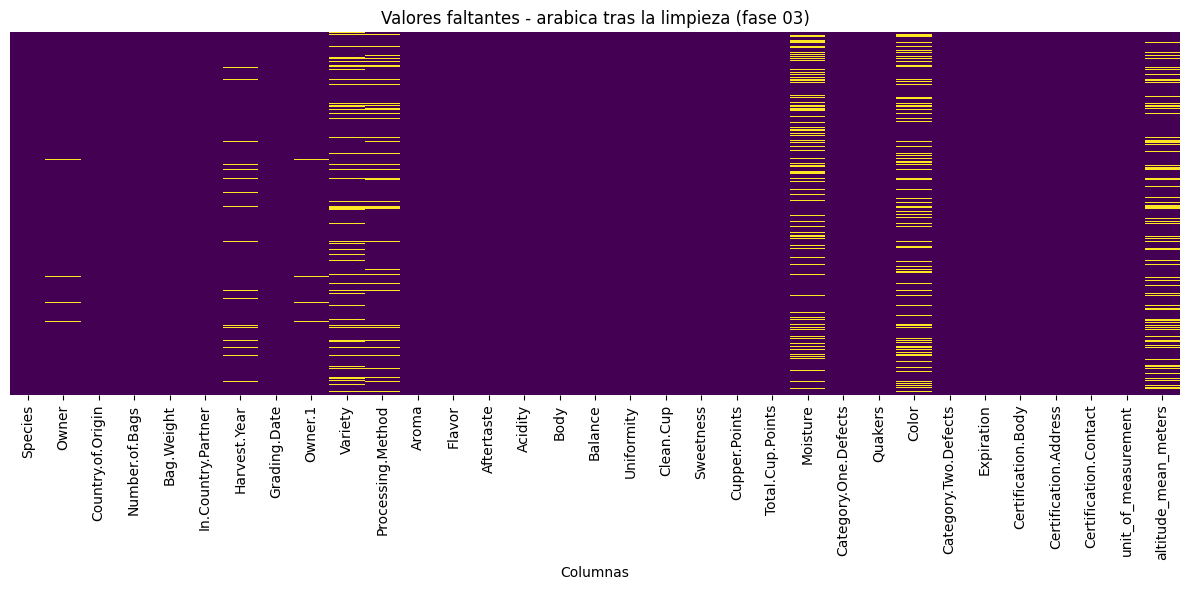

In [106]:
# Mapa de calor de los valores faltantes tras la limpieza (solo arabica)
import matplotlib.pyplot as plt
from src.visualization.plots import plot_missing_matrix

plot_missing_matrix(df, config, "nulos_arabica_limpio.png",
                    title="Valores faltantes - arabica tras la limpieza (fase 03)")
plt.show()

In [107]:
# ¿El registro con Quakers nulo es el mismo que el de Country.of.Origin nulo?
fila_quakers = df.index[df["Quakers"].isna()].tolist()
fila_pais    = df.index[df["Country.of.Origin"].isna()].tolist()
print("Fila(s) con Quakers nulo          :", fila_quakers)
print("Fila(s) con Country.of.Origin nulo:", fila_pais)

Fila(s) con Quakers nulo          : [366]
Fila(s) con Country.of.Origin nulo: [1197]


## 3.6 Reducción de variables: quitar lo que no aporta al análisis

Después de la limpieza, `df` todavía tiene **33 columnas**, muchas de las cuales no sirven ni para el clustering (que usará los subpuntajes de catación) ni para el perfilado posterior de los grupos (origen, manejo y calidad física del grano). Se eliminan en dos pasos.

### 3.6.1 `Species` es constante

Al trabajar solo con arabica (sección 3.5), `Species` vale `"Arabica"` en las 1310 filas, por lo tanto no está aportando información, así que se elimina.

In [108]:
print("Valores únicos de Species:", df["Species"].unique())
df = df.drop(columns=["Species"])
print("df tras quitar Species:", df.shape)

Valores únicos de Species: ['Arabica']
df tras quitar Species: (1310, 32)


### 3.6.2 Columnas administrativas y de identificación

Varias columnas resultaron ser información administrativa del lote (finca, propietario, certificadora), no características del café. Antes de eliminar ninguna, se analizó cada candidata: cuántos **valores distintos** toma, qué **porcentaje del total** representan y el **% de nulos actual**.

In [109]:
COLUMNAS_ADMIN = [
    "Owner", "Owner.1",
    "Certification.Body", "Certification.Address", "Certification.Contact",
    "In.Country.Partner", "Grading.Date", "Expiration",
    "Bag.Weight", "unit_of_measurement", "Number.of.Bags",
]

n = len(df)
resumen_admin = pd.DataFrame({
    "n_valores_distintos": [df[c].nunique(dropna=True) for c in COLUMNAS_ADMIN],
    "%_valores_unicos": [round(df[c].nunique(dropna=True) / n * 100, 1) for c in COLUMNAS_ADMIN],
    "%_nulos": [round(df[c].isna().mean() * 100, 1) for c in COLUMNAS_ADMIN],
    "ejemplos": [", ".join(map(str, df[c].dropna().unique()[:3])) for c in COLUMNAS_ADMIN],
}, index=COLUMNAS_ADMIN)
resumen_admin

,n_valores_distintos,%_valores_unicos,%_nulos,ejemplos
Owner,305,23.3,0.5,"metad plc, grounds for health admin, yidnekach..."
Owner.1,309,23.6,0.5,"metad plc, Grounds for Health Admin, Yidnekach..."
Certification.Body,26,2.0,0.0,"METAD Agricultural Development plc, Specialty ..."
Certification.Address,30,2.3,0.0,"309fcf77415a3661ae83e027f7e5f05dad786e44, 36d0..."
Certification.Contact,27,2.1,0.0,"19fef5a731de2db57d16da10287413f5f99bc2dd, 0878..."
In.Country.Partner,27,2.1,0.0,"METAD Agricultural Development plc, Specialty ..."
Grading.Date,558,42.6,0.0,"April 4th, 2015, May 31st, 2010, March 26th, 2015"
Expiration,557,42.5,0.0,"April 3rd, 2016, May 31st, 2011, March 25th, 2016"
Bag.Weight,56,4.3,0.0,"60 kg, 1, 30 kg"
unit_of_measurement,2,0.2,0.0,"m, ft"


In [110]:
# ¿Alguna de las columnas admin con pocas categorías aporta una clasificación útil?
UMBRAL_POCAS_CATEGORIAS = 60

pocas = [c for c in COLUMNAS_ADMIN if df[c].nunique(dropna=True) < UMBRAL_POCAS_CATEGORIAS]
print(f"Columnas admin con < {UMBRAL_POCAS_CATEGORIAS} valores distintos: {pocas}")
print()
for c in pocas:
    print(f"--- {c}  ({df[c].nunique(dropna=True)} valores distintos) ---")
    print(df[c].value_counts(dropna=False).head(6))
    print()

Columnas admin con < 60 valores distintos: ['Certification.Body', 'Certification.Address', 'Certification.Contact', 'In.Country.Partner', 'Bag.Weight', 'unit_of_measurement']

--- Certification.Body  (26 valores distintos) ---
Certification.Body
Specialty Coffee Association           295
AMECAFE                                205
Almacafé                               178
Asociacion Nacional Del Café           155
Brazil Specialty Coffee Association     67
Instituto Hondureño del Café            59
Name: count, dtype: int64

--- Certification.Address  (30 valores distintos) ---
Certification.Address
36d0d00a3724338ba7937c52a378d085f2172daa    293
59e396ad6e22a1c22b248f958e1da2bd8af85272    204
e493c36c2d076bf273064f7ac23ad562af257a25    178
b1f20fe3a819fd6b2ee0eb8fdc3da256604f1e53    155
3297cfa4c538e3dd03f72cc4082c54f7999e1f9d     67
b4660a57e9f8cc613ae5b8f02bfce8634c763ab4     59
Name: count, dtype: int64

--- Certification.Contact  (27 valores distintos) ---
Certification.Contact
08

**Análisis, columna por columna:**

| Columna | Qué muestra el análisis | Por qué se elimina |
|---|---|---|
| `Owner`, `Owner.1` | Tienen alrededor de 305 valores distintos, además, `Owner.1` resulta ser una copia de `Owner`, con la escritura apenas distinta. | Es un identificador del propietario del lote, no una característica del café. |
| `Certification.Address`, `Certification.Contact` | Tienen entre 27 y 30 valores distintos, pero se trata de cadenas de texto cifradas, imposibles de interpretar. | Son datos de contacto anonimizados: no son legibles ni tienen valor analítico. |
| `Certification.Body`, `In.Country.Partner` | Tienen entre 26 y 27 valores distintos, correspondientes a nombres de organizaciones certificadoras o de contacto en el país de origen. | Indican quién certificó o acompañó el proceso de catación, no una propiedad del lote. |
| `Grading.Date`, `Expiration` | Tienen entre 557 y 558 valores distintos, con fechas escritas en texto libre. | Son fechas del proceso de catación o del vencimiento de la muestra, no del cultivo; el año de cosecha ya está capturado en `Harvest.Year`. |
| `Bag.Weight` | Tiene 56 valores que mezclan distintas unidades (`1 kg`, `69 kg`, `100 lbs`, entre otras). | Refleja el peso del empaque de la muestra enviada: es un dato logístico, no de calidad del café. |
| `unit_of_measurement` | Solo tiene 2 valores: metros (1128 lotes) y pies (182 lotes). | Es la unidad en que originalmente venía registrada la altitud; como ya se trabaja con `altitude_mean_meters` en metros, y las columnas de altitud sin procesar se eliminaron en la sección 3.4.2, esta columna queda huérfana. |
| `Number.of.Bags` | Tiene 130 valores distintos, sin datos faltantes. | Representa el tamaño del lote, un dato logístico. La fase 02 ya la había señalado como no crítica, y su correlación con las demás variables es prácticamente nula. |

In [111]:
df = df.drop(columns=[c for c in COLUMNAS_ADMIN if c in df.columns])
print("df tras quitar columnas administrativas:", df.shape)
print(sorted(df.columns))

df tras quitar columnas administrativas: (1310, 21)
['Acidity', 'Aftertaste', 'Aroma', 'Balance', 'Body', 'Category.One.Defects', 'Category.Two.Defects', 'Clean.Cup', 'Color', 'Country.of.Origin', 'Cupper.Points', 'Flavor', 'Harvest.Year', 'Moisture', 'Processing.Method', 'Quakers', 'Sweetness', 'Total.Cup.Points', 'Uniformity', 'Variety', 'altitude_mean_meters']


Después de analizar cada una de las variables administrativas y de eliminarlas, la base de datos que queda se puede dividir en tres grupos:

| Grupo | Variables | Para qué |
|---|---|---|
| **Catación (SCA)** | `Aroma`, `Flavor`, `Aftertaste`, `Acidity`, `Body`, `Balance`, `Uniformity`, `Clean.Cup`, `Sweetness`, `Cupper.Points` | **Entrada del clustering** |
| **Puntaje total** | `Total.Cup.Points` | **Referencia** |
| **Perfilado** | `Country.of.Origin`, `altitude_mean_meters`, `Variety`, `Processing.Method`, `Harvest.Year`, `Color`, `Moisture`, `Category.One.Defects`, `Category.Two.Defects`, `Quakers` | **Describir los grupos** |

## 3.7 Análisis de redundancia: matrices de correlación

Antes de fijar el dataset final, revisamos si hay variables redundantes.

### 3.7.1 Subpuntajes de catación

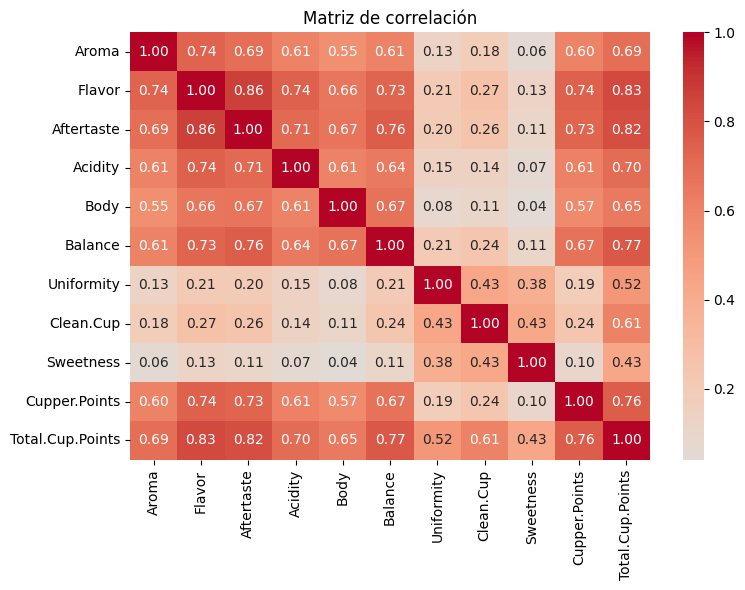

In [112]:
import matplotlib.pyplot as plt
from src.visualization.plots import plot_correlation_heatmap

SCA = ["Aroma", "Flavor", "Aftertaste", "Acidity", "Body", "Balance",
       "Uniformity", "Clean.Cup", "Sweetness", "Cupper.Points"]

plot_correlation_heatmap(df, SCA + ["Total.Cup.Points"], config,
                         "corr_subpuntajes_sca.png")
plt.show()

**Hallazgo.** La matriz de correlación deja ver dos grupos bien diferenciados.

El primero agrupa ocho variables que se mueven casi al mismo ritmo: los seis atributos de perfil de taza (`Aroma`, `Flavor`, `Aftertaste`, `Acidity`, `Body` y `Balance`), junto con `Cupper.Points` y `Total.Cup.Points`. En conjunto, este bloque resulta bastante redundante, pues un lote que puntúa alto en uno de estos atributos tiende a puntuar alto en todos los demás.

El segundo grupo lo forman `Uniformity`, `Clean.Cup` y `Sweetness`, que se comportan aparte del resto. Se correlacionan poco con el bloque de taza, por debajo de 0.3, y entre sí solo alcanzan cerca de 0.4, algo que coincide con lo que ya se había visto en la fase 02, donde estos atributos resultaron casi constantes en los lotes evaluados. Con `Total.Cup.Points` sí suben un poco, entre 0.43 y 0.61, pero esto es consecuencia de que forman parte de una suma, no de una relación real con el resto de los atributos.

**Nota.** Nos toca decidir como manejar esta redundancia (mantener los diez subpuntajes tal como están, combinarlos en una nueva variable que resuma el bloque, o comprimirlos mediante PCA). Por ahora ningún subpuntaje se elimina, porque son la materia prima del clustering.

### 3.7.2 Variables numéricas de perfilado y calidad física

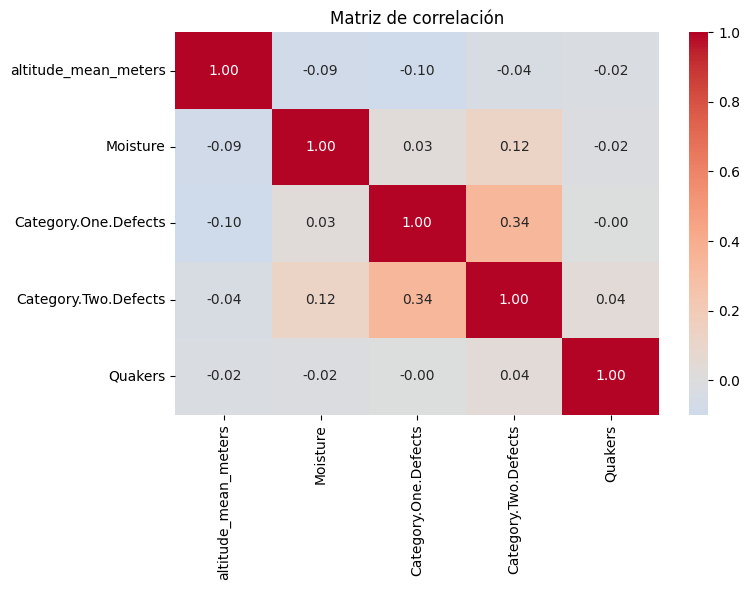

In [113]:
NUM_PERFIL = ["altitude_mean_meters", "Moisture", "Category.One.Defects",
              "Category.Two.Defects", "Quakers"]
plot_correlation_heatmap(df, NUM_PERFIL, config, "corr_numericas_perfilado.png")
plt.show()

In [114]:
c1, c2 = "Category.One.Defects", "Category.Two.Defects"

print(f"% de lotes con {c1} == 0:", round((df[c1] == 0).mean() * 100, 1))
print(f"% de lotes con {c2} == 0:", round((df[c2] == 0).mean() * 100, 1))
print()
print("Filas con el mismo valor en ambas:", int((df[c1] == df[c2]).sum()), "de", len(df),
      "(casi todas son ambos = 0)")
print("Correlación solo entre lotes con algún defecto:",
      round(df.loc[(df[c1] > 0) | (df[c2] > 0), [c1, c2]].corr().iloc[0, 1], 3))

% de lotes con Category.One.Defects == 0: 84.7
% de lotes con Category.Two.Defects == 0: 27.6

Filas con el mismo valor en ambas: 361 de 1310 (casi todas son ambos = 0)
Correlación solo entre lotes con algún defecto: 0.316


**Hallazgo.** Entre las variables de calidad física no hay señales de redundancia: la correlación más alta es la que hay entre `Category.One.Defects` y `Category.Two.Defects`, apenas 0.34, y todos los demás pares están por debajo de 0.2.

Esa correlación moderada entre las dos categorías de defectos tiene una explicación sencilla: ambas reflejan el mismo problema de fondo, un mal manejo en la poscosecha, el secado o el almacenamiento del grano, así que un lote descuidado tiende a acumular defectos de los dos tipos a la vez.

### 3.7.3 Variables categóricas de perfilado usando V de Cramér

In [115]:
import numpy as np

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    n = ct.to_numpy().sum()
    row = ct.sum(axis=1).to_numpy()
    col = ct.sum(axis=0).to_numpy()
    esperado = np.outer(row, col) / n
    chi2 = (((ct.to_numpy() - esperado) ** 2) / esperado).sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

CAT_PERFIL = ["Country.of.Origin", "Variety", "Processing.Method", "Color"]
vmat = pd.DataFrame(index=CAT_PERFIL, columns=CAT_PERFIL, dtype=float)
for i in CAT_PERFIL:
    for j in CAT_PERFIL:
        vmat.loc[i, j] = cramers_v(df[i].fillna("NA"), df[j].fillna("NA"))
print(vmat.round(2))

print("\nCardinalidad y nulos:")
for c in ["Country.of.Origin", "Variety", "Processing.Method", "Color", "Harvest.Year"]:
    print(f"  {c:<20} {df[c].nunique(dropna=True):>3} categorías | {df[c].isna().mean()*100:.1f}% nulos")

                   Country.of.Origin  Variety  Processing.Method  Color
Country.of.Origin               1.00     0.46               0.40   0.33
Variety                         0.46     1.00               0.43   0.33
Processing.Method               0.40     0.43               1.00   0.32
Color                           0.33     0.33               0.32   1.00

Cardinalidad y nulos:
  Country.of.Origin     36 categorías | 0.1% nulos
  Variety               29 categorías | 15.3% nulos
  Processing.Method      5 categorías | 11.5% nulos
  Color                  3 categorías | 20.4% nulos
  Harvest.Year          10 categorías | 4.8% nulos


**Hallazgo.** Las variables categóricas de perfilado muestran una asociación moderada entre sí, con una V de Cramér de entre 0.32 y 0.46, lo cual tiene sentido ya que ciertas variedades y métodos de procesamiento son más comunes en ciertos países. Sin embargo, ninguna determina a otra, ya que no hay valores cercanos a 1, así que no son redundantes y por eso se conservan todas.

## 3.8 Dataset reducido: `df` listo para la fase de clustering

In [116]:
grupos = {
    "catacion (entrada clustering)": ["Aroma", "Flavor", "Aftertaste", "Acidity", "Body",
                                     "Balance", "Uniformity", "Clean.Cup", "Sweetness", "Cupper.Points"],
    "puntaje total (referencia)":   ["Total.Cup.Points"],
    "perfilado - origen y manejo":  ["Country.of.Origin", "altitude_mean_meters", "Variety",
                                     "Processing.Method", "Harvest.Year"],
    "perfilado - calidad fisica":   ["Color", "Moisture", "Category.One.Defects",
                                     "Category.Two.Defects", "Quakers"],
}
print(f"df final: {df.shape[0]} filas x {df.shape[1]} columnas\n")
for g, cols in grupos.items():
    faltan = [c for c in cols if c not in df.columns]
    print(f"[{g}] ({len(cols)})" + (f"  FALTAN: {faltan}" if faltan else ""))
    print("  " + ", ".join(cols))

todas = [c for gr in grupos.values() for c in gr]
sobran = [c for c in df.columns if c not in todas]
print(f"\nColumnas de df no clasificadas en ningún grupo: {sobran}")

df final: 1310 filas x 21 columnas

[catacion (entrada clustering)] (10)
  Aroma, Flavor, Aftertaste, Acidity, Body, Balance, Uniformity, Clean.Cup, Sweetness, Cupper.Points
[puntaje total (referencia)] (1)
  Total.Cup.Points
[perfilado - origen y manejo] (5)
  Country.of.Origin, altitude_mean_meters, Variety, Processing.Method, Harvest.Year
[perfilado - calidad fisica] (5)
  Color, Moisture, Category.One.Defects, Category.Two.Defects, Quakers

Columnas de df no clasificadas en ningún grupo: []


In [117]:
# Estado de nulos del dataset reducido
nulos = pd.DataFrame({
    "n_nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(1),
})
print(nulos[nulos["n_nulos"] > 0].sort_values("n_nulos", ascending=False))

                      n_nulos  %_nulos
altitude_mean_meters      278     21.2
Color                     267     20.4
Moisture                  252     19.2
Variety                   201     15.3
Processing.Method         151     11.5
Harvest.Year               63      4.8
Country.of.Origin           1      0.1
Quakers                     1      0.1


## 3.9 Imputación de las variables de perfilado

Del cuadro preocupan cinco variables con un alto porcentaje de nulidad: `altitude_mean_meters` (~21 %), `Color` (~20 %), `Moisture` (~19 %), `Variety` (~15 %) y `Processing.Method` (~12 %).

El requisito real del clustering (sin nulos en las variables que se agrupan) ya se cumple: estas cinco no entran al agrupamiento, se usan después para perfilar. Se tratan igual, más por comodidad que por necesidad, para no arrastrar datos vacíos al comparar los grupos.

In [118]:
SCA = ["Aroma", "Flavor", "Aftertaste", "Acidity", "Body", "Balance",
       "Uniformity", "Clean.Cup", "Sweetness", "Cupper.Points"]
print("Nulos en los subpuntajes de catación:")
print(df[SCA].isna().sum())

Nulos en los subpuntajes de catación:
Aroma            0
Flavor           0
Aftertaste       0
Acidity          0
Body             0
Balance          0
Uniformity       0
Clean.Cup        0
Sweetness        0
Cupper.Points    0
dtype: int64


| Variable | % nulos | Tipo | Decisión | Motivo |
|---|---|---|---|---|
| `altitude_mean_meters` | ~21 % | numérica de perfilado | No se imputa (queda `NaN`) + indicador `altitude_reportada` | Decidido en 3.4.3: el faltante no es aleatorio y una mediana aplanaría justo lo que se quiere leer. Se perfila solo con los lotes que la reportan. |
| `Moisture` | ~19 % | numérica de perfilado | No se imputa (queda `NaN`) + indicador `humedad_reportada` | No entra al clustering; sus faltantes venían codificados como `0` (valor arbitrario), así que imputar sería inventar una medición. Se perfila solo con los lotes que la reportan. |
| `Harvest.Year` | ~5 % | numérica (año) | No se imputa (queda `NaN`) | Porcentaje bajo; no vale la pena inventar un año de cosecha. |
| `Color` | ~20 % | categórica | Se imputa como `"Desconocido"` | El faltante pasa a ser una categoría más, sin perder lotes en el dashboard. |
| `Variety` | ~15 % | categórica | Se imputa como `"Desconocido"` | Igual que `Color`. |
| `Processing.Method` | ~12 % | categórica | Se imputa como `"Desconocido"` | Igual que `Color`. |
| `Country.of.Origin` | 1 lote | categórica | Se imputa como `"Desconocido"` | Es la fila 1197, que tiene la catación completa (`Total.Cup.Points` 79), así que se conserva. |
| `Quakers` | 1 lote | numérica | Se imputa con `0` | Es la fila 366; `0` es el valor en cerca del 99 % de los lotes. |

In [122]:
# Categóricas de perfilado -> 'Desconocido'
for c in ["Color", "Variety", "Processing.Method", "Country.of.Origin"]:
    df[c] = df[c].astype("object").fillna("Desconocido")

# Quakers: el único nulo -> 0
df["Quakers"] = df["Quakers"].fillna(0)

# Numéricas de perfilado que NO se imputan: se agrega un indicador de faltante
df["altitude_reportada"] = df["altitude_mean_meters"].notna().astype(int)
df["humedad_reportada"]  = df["Moisture"].notna().astype(int)

# Estado de nulos tras la imputación
nulos = pd.DataFrame({
    "n_nulos": df.isna().sum(),
    "%_nulos": (df.isna().mean() * 100).round(1),
})
print("Nulos que quedan (a propósito, en variables de perfilado numéricas):")
print(nulos[nulos["n_nulos"] > 0].sort_values("n_nulos", ascending=False))
print("\ndf:", df.shape)

Nulos que quedan (a propósito, en variables de perfilado numéricas):
                      n_nulos  %_nulos
altitude_mean_meters      278     21.2
Moisture                  252     19.2
Harvest.Year               63      4.8

df: (1310, 23)


**Hallazgo.** Tras la imputación, los únicos nulos que quedan son los de `altitude_mean_meters`, `Moisture` y `Harvest.Year`, **dejados a propósito** porque son variables de perfilado numéricas que no entran al clustering y que no tiene sentido inventar. Para las dos primeras se agregó un indicador (`altitude_reportada`, `humedad_reportada`) que permite, revisar si “no haber reportado el dato” está asociado a algún grupo en las fases siguientes.

## 3.10 Construcción de la matriz de entrada del clustering

La matriz de entrada es la tabla que recibe el algoritmo: debe ser completamente numérica y tener todas las columnas en la misma escala, porque el clustering agrupa por distancia.

### Qué columnas entran

Solo los subpuntajes de catación, que describen cómo sabe el café. De los diez, se dejan fuera `Uniformity`, `Clean.Cup` y `Sweetness`, porque se vio que son casi constantes, por lo que no ayudarían a separar lotes, solo añaden ruido (fase 02). Con esto en mente nos quedarían siete atributos: `Aroma`, `Flavor`, `Aftertaste`, `Acidity`, `Body`, `Balance` y `Cupper.Points`.

### Estandarización

Se aplica `StandardScaler`, que deja cada columna con media 0 y desviación 1. Los siete atributos van de 0 a 10, pero no tienen la misma dispersión: sin estandarizar, los que varían más pesarían más en la distancia.

In [120]:
from sklearn.preprocessing import StandardScaler

CLUSTERING_FEATURES = config["clustering"]["features"]
print("Atributos que entran al clustering:", CLUSTERING_FEATURES)
print("Nulos en esas columnas:", int(df[CLUSTERING_FEATURES].isna().sum().sum()))

scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(df[CLUSTERING_FEATURES]),
    columns=CLUSTERING_FEATURES,
    index=df.index,
)

print("\nAntes de estandarizar (media / desv.):")
print(df[CLUSTERING_FEATURES].agg(['mean', 'std']).round(2))
print("\nDespués de estandarizar (media / desv.):")
print(X.agg(['mean', 'std']).round(2))
print("\nMatriz de entrada del clustering:", X.shape)

Atributos que entran al clustering: ['Aroma', 'Flavor', 'Aftertaste', 'Acidity', 'Body', 'Balance', 'Cupper.Points']
Nulos en esas columnas: 0

Antes de estandarizar (media / desv.):
      Aroma  Flavor  Aftertaste  Acidity  Body  Balance  Cupper.Points
mean   7.57    7.52        7.40     7.54  7.52     7.52           7.50
std    0.32    0.34        0.35     0.32  0.29     0.35           0.43

Después de estandarizar (media / desv.):
      Aroma  Flavor  Aftertaste  Acidity  Body  Balance  Cupper.Points
mean    0.0     0.0        -0.0     -0.0   0.0     -0.0           -0.0
std     1.0     1.0         1.0      1.0   1.0      1.0            1.0

Matriz de entrada del clustering: (1310, 7)


In [121]:
from src.config import resolve_path

processed_dir = resolve_path(config["paths"]["data"]["processed_dir"])
processed_dir.mkdir(parents=True, exist_ok=True)

# 1) Matriz de entrada del clustering (estandarizada)
X.to_csv(processed_dir / "clustering_input.csv", index=False)

# 2) Dataset limpio y reducido, con perfilado + Total.Cup.Points (para fases 05-06)
df.to_csv(processed_dir / "coffee_clean.csv", index=False)

# 3) Parámetros del scaler (para revertir la estandarización en la fase 06)
import json
scaler_params = {
    "features": list(CLUSTERING_FEATURES),
    "mean": scaler.mean_.tolist(),
    "scale": scaler.scale_.tolist(),
}
(processed_dir / "clustering_scaler.json").write_text(
    json.dumps(scaler_params, indent=2), encoding="utf-8")

print("Guardado en data/processed/:")
print("  clustering_input.csv   ->", X.shape)
print("  coffee_clean.csv       ->", df.shape)
print("  clustering_scaler.json ->", len(CLUSTERING_FEATURES), "features")

Guardado en data/processed/:
  clustering_input.csv   -> (1310, 7)
  coffee_clean.csv       -> (1310, 23)
  clustering_scaler.json -> 7 features


## 3.11 Qué se debe hacer en las fases siguientes

De esta fase salen tres artefactos en `data/processed/`: `clustering_input.csv` (la matriz 1 310 × 7 estandarizada), `coffee_clean.csv` (el dataset reducido con las variables de perfilado y `Total.Cup.Points`) y `clustering_scaler.json` (para revertir la estandarización). A partir de ellos, estas son las tareas concretas que le corresponden a cada fase siguiente.

### Modelado (parte de `clustering_input.csv`)

| Tarea | Detalle |
|---|---|
| Evaluar PCA | Comparar el clustering sobre los 7 atributos estandarizados frente a una versión reducida con PCA (scree plot, % de varianza acumulada), y decidir si se usa y con cuántos componentes. |
| Comparar algoritmos | Probar los de `config.yaml -> clustering.algorithms`: k-means, aglomerativo y *gaussian mixture*. |
| Elegir el número de grupos *k* | En el rango `clustering.k_min`-`clustering.k_max` (2 a 10), usando el coeficiente de silueta como métrica principal. |
| Fijar hiperparámetros | Los del algoritmo elegido van en `config.yaml -> clustering.algorithms`, no sueltos en el notebook. |
| Guardar el modelo | Modelo final y etiqueta de grupo por lote, en `models/`. |

### Evaluación (parte de `models/` y `coffee_clean.csv`)

| Tarea | Detalle |
|---|---|
| Validación interna | Silueta, Davies-Bouldin y Calinski-Harabasz (`config -> validation.internal_metrics`). |
| Estabilidad | Repetir el agrupamiento con distintas semillas y submuestras, y ver si los grupos se mantienen. |
| Contraste externo | Cruzar los grupos con `Total.Cup.Points >= 80` (`config -> validation.reference_column` / `specialty_threshold`) para ver si el clustering reprodujo la convención de la industria o encontró algo distinto. |
| Criterios de éxito | Contrastar los resultados con los criterios definidos en la fase 01. |

### Interpretación (parte de `coffee_clean.csv` y `clustering_scaler.json`)

| Tarea | Detalle |
|---|---|
| Centros en unidades reales | Revertir la estandarización con `clustering_scaler.json` para describir cada grupo en puntos SCA, no en desviaciones. |
| Perfilar con categóricas | Distribución de `Country.of.Origin`, `Variety`, `Processing.Method` y `Color` por grupo, ya imputadas como `"Desconocido"` donde faltaban. |
| Perfilar con numéricas de perfilado | `altitude_mean_meters`, `Moisture` y `Harvest.Year`: calcular las estadísticas solo sobre los lotes que reportan el dato, mostrando el *n* de cada grupo. Usar `altitude_reportada` y `humedad_reportada` para revisar si no reportar el dato está asociado a algún grupo en particular. |
| Perfilar con defectos | `Category.One.Defects`, `Category.Two.Defects` y `Quakers` por grupo. |
| Cautelas al interpretar | Países con muy pocos lotes, sesgo de selección porque la base son lotes que buscan certificación, y que robusta quedó fuera del análisis. |
| Dashboard | Exportar el dataset plano (grupo más variables de perfilado) para Power BI o Tableau. |
